# Intelligent Property Price Prediction 🏡

**Course**: Mid-Sem Project (Milestone 1)  
**Objective**: Predict property prices using traditional Machine Learning.

### 1. Data Preprocessing

In [172]:
import pandas as pd
df = pd.read_csv('../data/india_housing_prices.csv')
print(f"Dataset Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})\n")
display(df.head())

Dataset Shape: (250000, 23) (Rows: 250000, Columns: 23)



,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [173]:
# Dropping these columns as it has no role in model training and might produce unwanted noise
df.drop(columns=['ID', 'Price_per_SqFt', 'Year_Built', 'Availability_Status','Owner_Type','Facing','Amenities','Locality','Floor_No','Nearby_Schools','Nearby_Hospitals',], inplace=True)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   State                           250000 non-null  str    
 1   City                            250000 non-null  str    
 2   Property_Type                   250000 non-null  str    
 3   BHK                             250000 non-null  int64  
 4   Size_in_SqFt                    250000 non-null  int64  
 5   Price_in_Lakhs                  250000 non-null  float64
 6   Furnished_Status                250000 non-null  str    
 7   Total_Floors                    250000 non-null  int64  
 8   Age_of_Property                 250000 non-null  int64  
 9   Public_Transport_Accessibility  250000 non-null  str    
 10  Parking_Space                   250000 non-null  str    
 11  Security                        250000 non-null  str    
dtypes: float64(1), int64(4), st

In [174]:
df.isnull().sum()


State                             0
City                              0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Furnished_Status                  0
Total_Floors                      0
Age_of_Property                   0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
dtype: int64

In [175]:
df.duplicated().sum()

np.int64(0)

In [176]:
df.describe()

,BHK,Size_in_SqFt,Price_in_Lakhs,Total_Floors,Age_of_Property
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,2.999396,2749.813216,254.586854,15.503004,18.479988
std,1.415521,1300.606954,141.349921,8.671618,9.808575
min,1.000000,500.000000,10.000000,1.000000,2.000000
25%,2.000000,1623.000000,132.550000,8.000000,10.000000
50%,3.000000,2747.000000,253.870000,15.000000,18.000000
75%,4.000000,3874.000000,376.880000,23.000000,27.000000
max,5.000000,5000.000000,500.000000,30.000000,35.000000


The data has no missing values or any anomalies. We can proceed further with Data encoding of categorical dataset and prepare it for model training.

In [177]:
# Display unique values for each categorical column
categorical_cols = ['Property_Type','Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security']

for col in categorical_cols:
  print(f"{col}: {df[col].unique()}")
  print(f"Number of unique values: {df[col].nunique()}\n")

Property_Type: <StringArray>
['Apartment', 'Independent House', 'Villa']
Length: 3, dtype: str
Number of unique values: 3

Furnished_Status: <StringArray>
['Furnished', 'Unfurnished', 'Semi-furnished']
Length: 3, dtype: str
Number of unique values: 3

Public_Transport_Accessibility: <StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
Number of unique values: 3

Parking_Space: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2

Security: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2



### Data Encoding
- **Property_Type**  
  → One-Hot Encoded to avoid introducing false ordering between categories.

- **Furnished_Status**  
  → Ordinal Encoded (`Unfurnished=0`, `Semi-furnished=1`, `Furnished=2`) since it has a natural order.

- **Public_Transport_Accessibility**  
  → Ordinal Encoded (`Low=0`, `Medium=1`, `High=2`) to preserve ranking.

- **Parking_Space**  
  → Binary Encoded (`No=0`, `Yes=1`).

- **Security**  
  → Binary Encoded (`No=0`, `Yes=1`).

In [178]:
from sklearn.preprocessing import OneHotEncoder

# start from a fresh copy so we don’t overwrite the original
df_encoded = df.copy()

# 1. One‑hot encode `Property_Type` (no implicit ordering)

ohe = OneHotEncoder(sparse_output=False)
prop_array = ohe.fit_transform(df_encoded[['Property_Type']])
prop_cols = ohe.get_feature_names_out(['Property_Type'])

df_encoded = pd.concat(
  [df_encoded.drop(columns=['Property_Type']),
   pd.DataFrame(prop_array, columns=prop_cols, index=df_encoded.index)],
  axis=1
)

# 2. Ordinal encode `Furnished_Status`
furnish_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Furnished': 2}
df_encoded['Furnished_Status'] = df_encoded['Furnished_Status'].map(furnish_map)

# 3. Ordinal encode `Public_Transport_Accessibility`
trans_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['Public_Transport_Accessibility'] = df_encoded['Public_Transport_Accessibility'].map(trans_map)

# 4. Binary encode `Parking_Space`
df_encoded['Parking_Space'] = df_encoded['Parking_Space'].map({'No': 0, 'Yes': 1})

# 5. Binary encode `Security`
df_encoded['Security'] = df_encoded['Security'].map({'No': 0, 'Yes': 1})

# inspect the result
df_encoded.head()

,State,City,BHK,Size_in_SqFt,Price_in_Lakhs,Furnished_Status,Total_Floors,Age_of_Property,Public_Transport_Accessibility,Parking_Space,Security,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa
0,Tamil Nadu,Chennai,1,4740,489.76,2,1,35,2,0,0,1.0,0.0,0.0
1,Maharashtra,Pune,3,2364,195.52,0,20,17,0,0,1,0.0,1.0,0.0
2,Punjab,Ludhiana,2,3642,183.79,1,27,28,0,1,0,1.0,0.0,0.0
3,Rajasthan,Jodhpur,2,2741,300.29,2,26,34,2,1,1,0.0,1.0,0.0
4,Rajasthan,Jaipur,4,4823,182.90,1,2,23,0,0,1,0.0,0.0,1.0


### Encoding State and City

- **State** → Frequency Encoded  
- **City** → Frequency Encoded  

Both columns were converted from text to numerical form by replacing each category with its occurrence frequency in the dataset.

The original `State` and `City` columns were then dropped.

This ensures the dataset is fully numeric and ready for Random Forest training.

In [179]:
# Frequency encode State and City columns
state_freq = df_encoded['State'].value_counts(normalize=True).to_dict()
city_freq = df_encoded['City'].value_counts(normalize=True).to_dict()

df_encoded['State'] = df_encoded['State'].map(state_freq)
df_encoded['City'] = df_encoded['City'].map(city_freq)

df_encoded.head()

,State,City,BHK,Size_in_SqFt,Price_in_Lakhs,Furnished_Status,Total_Floors,Age_of_Property,Public_Transport_Accessibility,Parking_Space,Security,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa
0,0.050516,0.024672,1,4740,489.76,2,1,35,2,0,0,1.0,0.0,0.0
1,0.050132,0.016896,3,2364,195.52,0,20,17,0,0,1,0.0,1.0,0.0
2,0.050064,0.025180,2,3642,183.79,1,27,28,0,1,0,1.0,0.0,0.0
3,0.049608,0.024684,2,2741,300.29,2,26,34,2,1,1,0.0,1.0,0.0
4,0.049608,0.024924,4,4823,182.90,1,2,23,0,0,1,0.0,0.0,1.0


### Winsorize & Log Transform
- Clip `Size_in_SqFt` at 1st and 99th percentiles to reduce outlier impact.
- Create `log_size` using `log1p` for better distribution stability.
- Create `log_price` (target) to reduce skew and improve model learning.

In [180]:
import numpy as np

p_low, p_high = df_encoded['Size_in_SqFt'].quantile([0.01, 0.99])

df_encoded['Size_in_SqFt_clipped'] = df_encoded['Size_in_SqFt'].clip(p_low, p_high)

df_encoded['log_size'] = np.log1p(df_encoded['Size_in_SqFt_clipped'])
df_encoded['log_price'] = np.log1p(df_encoded['Price_in_Lakhs'])

print(f"1st percentile (p_low): {p_low}")
print(f"99th percentile (p_high): {p_high}\n")
print(df_encoded[['Size_in_SqFt', 'Size_in_SqFt_clipped', 'log_size', 'Price_in_Lakhs', 'log_price']].head())

1st percentile (p_low): 545.0
99th percentile (p_high): 4956.0

   Size_in_SqFt  Size_in_SqFt_clipped  log_size  Price_in_Lakhs  log_price
0          4740                  4740  8.464003          489.76   6.195955
1          2364                  2364  7.768533          195.52   5.280764
2          3642                  3642  8.200563          183.79   5.219220
3          2741                  2741  7.916443          300.29   5.708073
4          4823                  4823  8.481359          182.90   5.214392


### Feature & Target Selection
- Define final feature list (numeric, encoded columns only).
- Create `X` (features) and `y` (`log_price` target).
- Confirm shapes before modeling.


In [181]:
features = ['State','City','BHK','log_size','Furnished_Status','Total_Floors','Age_of_Property',
      'Public_Transport_Accessibility','Parking_Space','Security',
      'Property_Type_Apartment','Property_Type_Independent House','Property_Type_Villa']

X = df_encoded[features]
y = df_encoded['log_price']

print("X.shape:", X.shape)
print("y.shape:", y.shape)
display(X.head(3))

X.shape: (250000, 13)
y.shape: (250000,)


,State,City,BHK,log_size,Furnished_Status,Total_Floors,Age_of_Property,Public_Transport_Accessibility,Parking_Space,Security,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa
0,0.050516,0.024672,1,8.464003,2,1,35,2,0,0,1.0,0.0,0.0
1,0.050132,0.016896,3,7.768533,0,20,17,0,0,1,0.0,1.0,0.0
2,0.050064,0.025180,2,8.200563,1,27,28,0,1,0,1.0,0.0,0.0


### Train/Test Split
- Split data into 80% training and 20% testing.
- Keep `random_state=42` for reproducibility.
- Test set remains untouched for final evaluation.


In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (200000, 13)
X_test shape: (50000, 13)
y_train shape: (200000,)
y_test shape: (50000,)


###  Pipeline + Baseline Random Forest
- Create numeric preprocessing pipeline (median imputation).
- Initialize `RandomForestRegressor` (300 trees, sqrt features, min_samples_leaf=2).
- Combine preprocessing + model into a single sklearn `Pipeline`.

In [183]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Define preprocessing pipeline
preprocessor = ColumnTransformer(
  transformers=[
    ('num', Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='median')),
      ('scaler', StandardScaler())
    ]), features)
  ]
)

# Initialize Random Forest model
rf_model = RandomForestRegressor(
  n_estimators=300,
  max_features='sqrt',
  random_state=42,
  n_jobs=-1
)

# Create full pipeline
pipeline = Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('model', rf_model)
])

print("Pipeline created successfully!")
print(pipeline)

Pipeline created successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['State', 'City', 'BHK',
                                                   'log_size',
                                                   'Furnished_Status',
                                                   'Total_Floors',
                                                   'Age_of_Property',
                                                   'Public_Transport_Accessibility',
                                                   'Parking_Space', 'Security',
                       

### Train Model
- Fit the pipeline on training data.
- Model learns patterns only from `X_train` and `y_train`.


In [184]:
import time

start = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - start

print("Training finished")
print(f"Elapsed time: {elapsed:.2f} seconds")

Training finished
Elapsed time: 11.98 seconds


### Cell 9 — Test Set Evaluation
- Predict on `X_test`.
- Convert predictions back from log scale.
- Compute MAE, RMSE, and R².
- Plot Actual vs Predicted and residual distribution.

MODEL EVALUATION ON TEST SET
Mean Absolute Error (MAE):  130.2790 Lakhs
Root Mean Squared Error (RMSE): 154.8465 Lakhs
R² Score: -0.2028


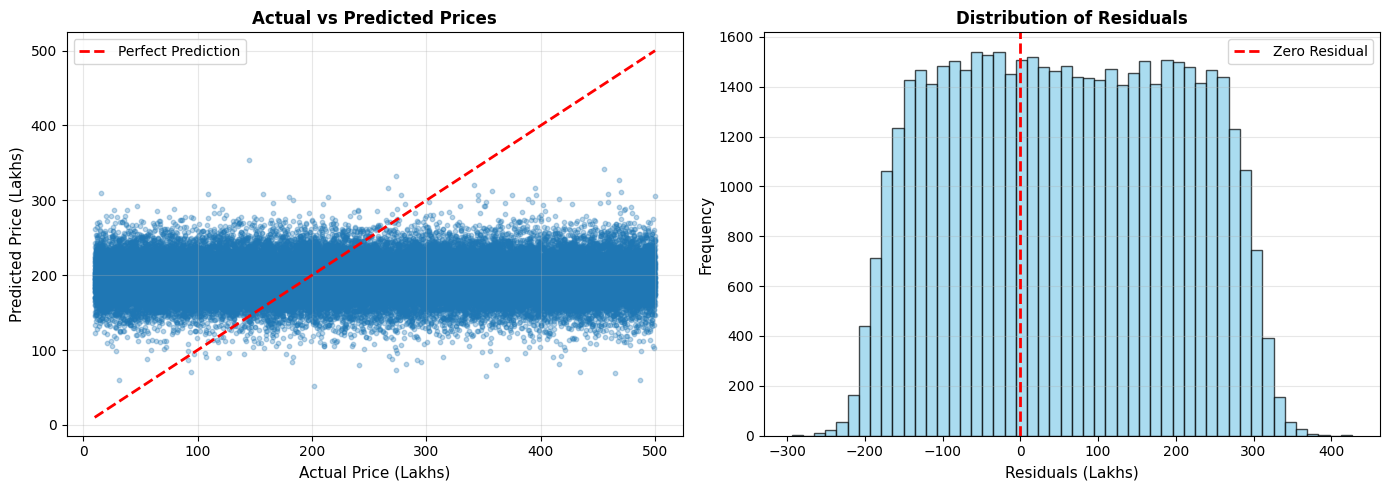

In [185]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# Make predictions on test set (in log scale)
y_pred_log = pipeline.predict(X_test)

# Convert back to original price scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Print metrics with clear labeling
print("=" * 50)
print("MODEL EVALUATION ON TEST SET")
print("=" * 50)
print(f"Mean Absolute Error (MAE):  {mae:.4f} Lakhs")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} Lakhs")
print(f"R² Score: {r2:.4f}")
print("=" * 50)

# Calculate residuals
residuals = y_true - y_pred

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (Lakhs)', fontsize=11)
axes[0].set_ylabel('Predicted Price (Lakhs)', fontsize=11)
axes[0].set_title('Actual vs Predicted Prices', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Residual')
axes[1].set_xlabel('Residuals (Lakhs)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Cross-Validation
- Perform 5-fold CV using full dataset.
- Generate out-of-fold predictions.
- Compute CV MAE, RMSE, and R² for stable performance estimate.

In [ ]:
from sklearn.model_selection import KFold, cross_val_predict

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_pred_log = cross_val_predict(pipeline, X, y, cv=kf, n_jobs=-1)

cv_pred = np.expm1(cv_pred_log)
cv_true = np.expm1(y)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("=" * 50)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 50)
print(f"CV Mean Absolute Error (MAE):  {cv_mae:.4f} Lakhs")
print(f"CV Root Mean Squared Error (RMSE): {cv_rmse:.4f} Lakhs")
print(f"CV R² Score: {cv_r2:.4f}")
print("=" * 50)

### Feature Importance
- Extract feature importances from trained Random Forest.
- Rank features by importance.
- Plot top contributors to price prediction.

In [ ]:
importances = pipeline.named_steps['model'].feature_importances_

feature_importances = pd.Series(importances, index=features).sort_values(ascending=False)

print("=" * 50)
print("TOP 15 FEATURE IMPORTANCES")
print("=" * 50)
print(feature_importances.head(15))
print("=" * 50)

fig, ax = plt.subplots(figsize=(10, 6))
feature_importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Features', fontsize=11)
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

###  Hyperparameter Tuning
- Use `RandomizedSearchCV` to explore better model settings.
- Optimize for lowest MAE.
- Select best-performing model configuration.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
  'model__n_estimators': [200, 300, 500],
  'model__min_samples_leaf': [1, 2, 3, 5],
  'model__max_depth': [None, 10, 20, 30],
  'model__max_features': ['sqrt', 'log2', 0.3, 0.5]
}

rs = RandomizedSearchCV(
  pipeline,
  param_dist,
  n_iter=20,
  cv=3,
  scoring='neg_mean_absolute_error',
  random_state=42,
  n_jobs=-1
)

rs.fit(X_train, y_train)

print("Best params:", rs.best_params_)
print("Best CV score (neg MAE):", rs.best_score_)

best_pipeline = rs.best_estimator_

### Final Evaluation + Save Model
- Evaluate tuned model on test set.
- Compare metrics to baseline.
- Save trained pipeline and preprocessing metadata for deployment.

In [ ]:
import joblib

y_pred_best_log = best_pipeline.predict(X_test)

y_pred_best = np.expm1(y_pred_best_log)
y_true_best = np.expm1(y_test)

mae_best = mean_absolute_error(y_true_best, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_true_best, y_pred_best))
r2_best = r2_score(y_true_best, y_pred_best)

print("=" * 50)
print("TUNED MODEL EVALUATION ON TEST SET")
print("=" * 50)
print(f"Mean Absolute Error (MAE):  {mae_best:.4f} Lakhs")
print(f"Root Mean Squared Error (RMSE): {rmse_best:.4f} Lakhs")
print(f"R² Score: {r2_best:.4f}")
print("=" * 50)

# Save the best pipeline
joblib.dump(best_pipeline, 'rf_property_pipeline.joblib')

# Save preprocessing metadata and mappings
metadata = {
  'furnish_map': furnish_map,
  'trans_map': trans_map,
  'state_freq': state_freq,
  'city_freq': city_freq,
  'p_low': p_low,
  'p_high': p_high,
  'features': features
}
joblib.dump(metadata, 'preprocessor_metadata.joblib')

print("Saved pipeline and metadata")